In [1]:
import shap

print(shap.__version__)

0.52.0


#### load saved diagnosis

In [2]:
import joblib

diagnosis_model = joblib.load(
    "../models/malaria_diagnosis_rf.pkl"
)

#### load diagnosis dataset

In [3]:
import pandas as pd


df = pd.read_csv(
    "../data/processed/diagnosis_final.csv"
)

X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

#### recreate train test split

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Transform Features

Because SHAP works on the transformed data:

In [5]:
preprocessor = diagnosis_model.named_steps["preprocessor"]

X_train_transformed = preprocessor.transform(X_train)

X_test_transformed = preprocessor.transform(X_test)

#### extract random forest

In [6]:
rf_classifier = diagnosis_model.named_steps["classifier"]

#### create SHAP explainer

In [7]:
explainer = shap.TreeExplainer(
    rf_classifier
)

#### generate SHAP values

In [8]:
shap_values = explainer.shap_values(
    X_test_transformed
)

#### recover feature names

In [9]:
categorical_cols = [
    "sex",
    "location"
]

numeric_cols = [
    col
    for col in X.columns
    if col not in categorical_cols
]

In [10]:
feature_names = (
    numeric_cols
    +
    list(
        preprocessor
        .named_transformers_["cat"]
        .get_feature_names_out(
            categorical_cols
        )
    )
)

### global feature importance

In [11]:
explainer = shap.TreeExplainer(
    rf_classifier
)

shap_values = explainer.shap_values(
    X_test_transformed,
    check_additivity=False
)

In [12]:
import numpy as np
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(1000, 43, 2)


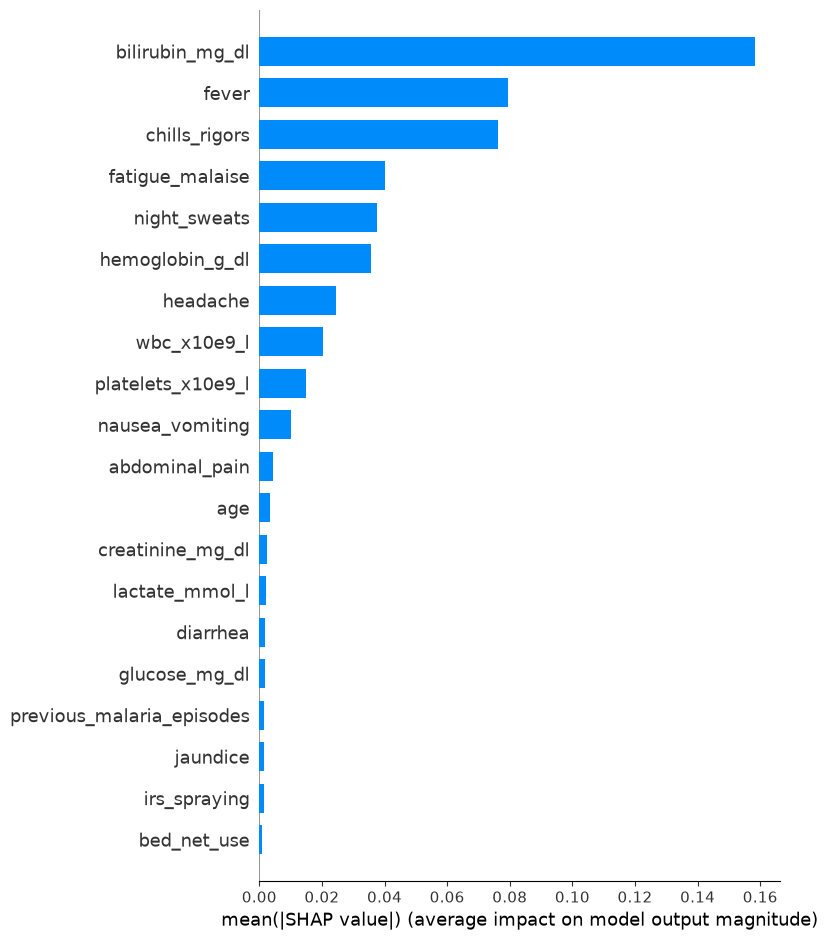

In [20]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)